# Title

Likelihood Ratio = 15

Prior Odds = 1:49

## Imports

In [25]:
import numpy as np

np.random.seed(42)

## Helpers

In [24]:
def odds_to_prob(odds):
    return odds / (1 + odds) 
    
def calc_post_odds(lr, prior_odds):
    return lr * prior_odds

## Calculate the Posterior

In [26]:
likelihood_ratio = 15
prior_odds = 1/49
post_odds = likelihood_ratio * prior_odds

print(f"Posterior Odds: {post_odds}")
print(f"Posterior Probs: {round(odds_to_prob(post_odds), 5)}")

likelihood_ratio = 15 
prior_odds = 1 / 49 
point_post_odds = calc_post_odds(likelihood_ratio, prior_odds) 
point_post_prob = odds_to_prob(point_post_odds) 
print(f"Point Posterior Odds: {point_post_odds:.4f}") 
print(f"Point Posterior Prob: {point_post_prob:.2%}")

Posterior Odds: 0.3061224489795918
Posterior Probs: 0.23437
Point Posterior Odds: 0.3061
Point Posterior Prob: 23.44%


LR with Gamma uncertainty of small sample size 1000

In [28]:
gamma_distribution = np.random.gamma(15, 1, 10000)

gamma_lr_samples = np.random.gamma(shape=15, scale=1.0, size=10000) 
post_odds_samples = calc_post_odds(gamma_lr_samples, prior_odds) 
post_prob_samples = odds_to_prob(post_odds_samples)

(array([1.160e+02, 1.383e+03, 3.540e+03, 3.018e+03, 1.415e+03, 4.230e+02,
        9.200e+01, 9.000e+00, 3.000e+00, 1.000e+00]),
 array([ 4.18981053,  7.70849836, 11.2271862 , 14.74587403, 18.26456186,
        21.7832497 , 25.30193753, 28.82062537, 32.3393132 , 35.85800103,
        39.37668887]),
 <BarContainer object of 10 artists>)

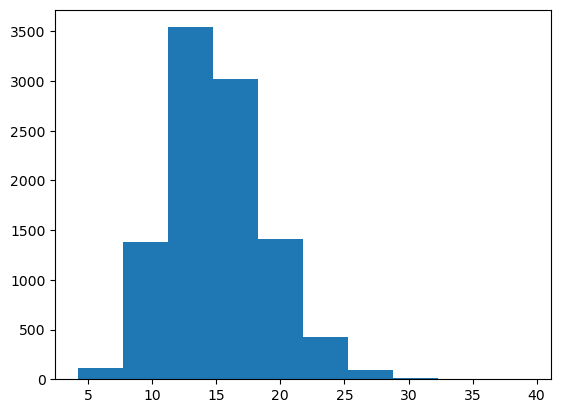

In [29]:
import matplotlib.pyplot as plt

plt.hist(gamma_distribution)

In [31]:
mean_prob = np.mean(post_prob_samples) 
p5 = np.percentile(post_prob_samples, 5) 
p95 = np.percentile(post_prob_samples, 95) 
print("--- Uncertainty Propagation Results ---") 
print(f"Mean Posterior Prob: {mean_prob:.2%}") 
print(f"95% Credible Interval: [{p5:.2%}, {p95:.2%}]")

--- Uncertainty Propagation Results ---
Mean Posterior Prob: 23.14%
95% Credible Interval: [15.95%, 30.98%]


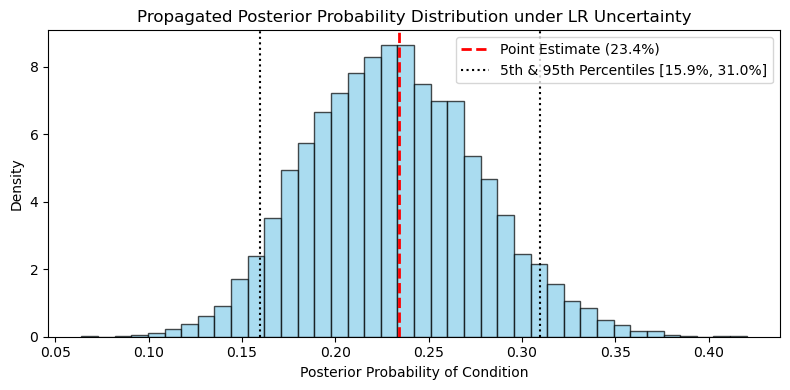

In [33]:
plt.figure(figsize=(8, 4)) 
plt.hist(
    post_prob_samples,
    bins=40,
    density=True,
    alpha=0.7,
    color="skyblue",
    edgecolor="black",
)

plt.axvline(
    point_post_prob,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Point Estimate ({point_post_prob:.1%})",
)
    
plt.axvline(
    p5,
    color="black",
    linestyle=":",
    linewidth=1.5,
    label=f"5th & 95th Percentiles [{p5:.1%}, {p95:.1%}]",
)

plt.axvline(
    p95,
    color="black",
    linestyle=":",
    linewidth=1.5,
)

plt.title(
    "Propagated Posterior Probability Distribution under LR Uncertainty"
) 
plt.xlabel("Posterior Probability of Condition") 
plt.ylabel("Density") 
plt.legend() 
plt.tight_layout() 
plt.show()

We observe that modeling the Likelihood Ratio with a Gamma distribution propagates parameter uncertainty directly into the posterior probability distribution. Rather than returning a single point estimate, this yields a full posterior curve with explicit **95% credible intervals**. This is critical in regulated environments and digital twins, where decision thresholds require honest risk bounds rather than overconfident point estimates.